# Data Exploration

Inspect the processed teammate telemetry and generate comparison plots for the selected team, session, and drivers.

## Team Selection

Choose the team, Grand Prix, and season that have already been processed. These parameters define the exact comparison window for the analysis.

In [1]:
team = "Aston Martin"
grand_prix = "Japanese Grand Prix"
year = 2025

## Imports and Configuration

Load dependencies, configure the notebook path, and prepare the modules used in the exploration steps.

In [2]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *

## Load Processed Data

Read the cached processed laps for both teammates so the notebook can work from already cleaned telemetry.

In [ ]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, team)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(year, grand_prix, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (598.78 MB) C:\Users\joseg\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


## Basic Data Inspection

Review the interpolated telemetry structure, summary statistics, and a few sample rows before plotting.

In [4]:
print(f"\n{lap_1['Driver']} interpolated telemetry data info:\n")
print(lap_1["Telemetry"].info())
print(f"\n{lap_2['Driver']} interpolated telemetry data info:\n")
print(lap_2["Telemetry"].info())

print(f"{lap_1['Driver']} interpolated telemetry description:\n\n {lap_1["Telemetry"].describe()}")
print(f"\n{lap_2['Driver']} interpolated telemetry description:\n\n {lap_2["Telemetry"].describe()}")

print(f"\n{lap_1['Driver']} interpolated telemetry head:\n\n {lap_1["Telemetry"].head()}")
print(f"\n{lap_2['Driver']} interpolated telemetry head:\n\n {lap_2["Telemetry"].head()}")


ALO interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  672 non-null    float64
 1   Time      672 non-null    float64
 2   Speed     672 non-null    float64
 3   RPM       672 non-null    int64  
 4   Throttle  672 non-null    float64
 5   nGear     672 non-null    int64  
 6   Brake     672 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 36.9 KB
None

STR interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  672 non-null    float64
 1   Time      672 non-null    float64
 2   Speed     672 non-null    float64
 3   RPM       672 non-null    int64  
 4   Throttle  672 non-null    float64
 5   nGear     672 non-null    i

## Variables' Comparison and Delta 

Compare selected telemetry variables visually and inspect the gap between the two teammates across the lap and the difference between the teammates for each selected telemetry variable.

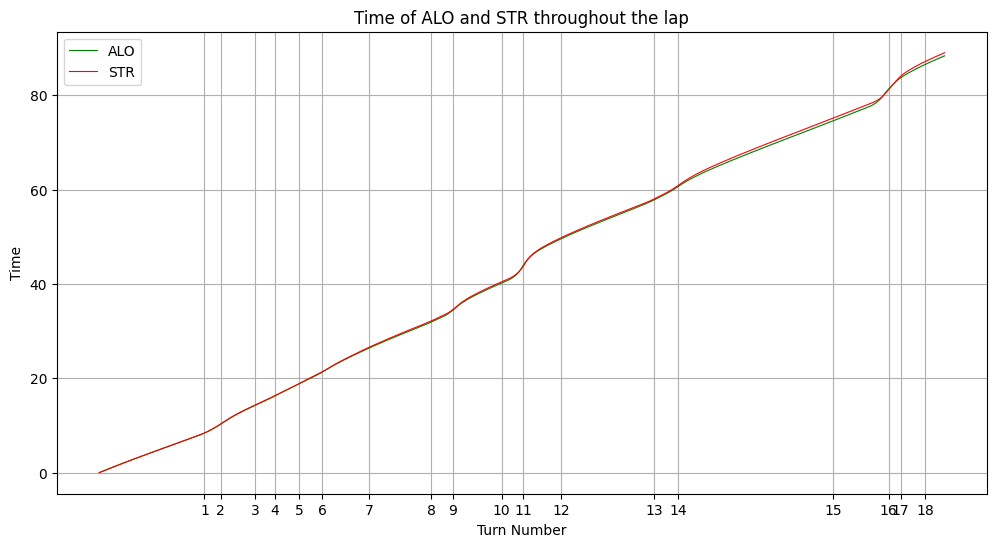

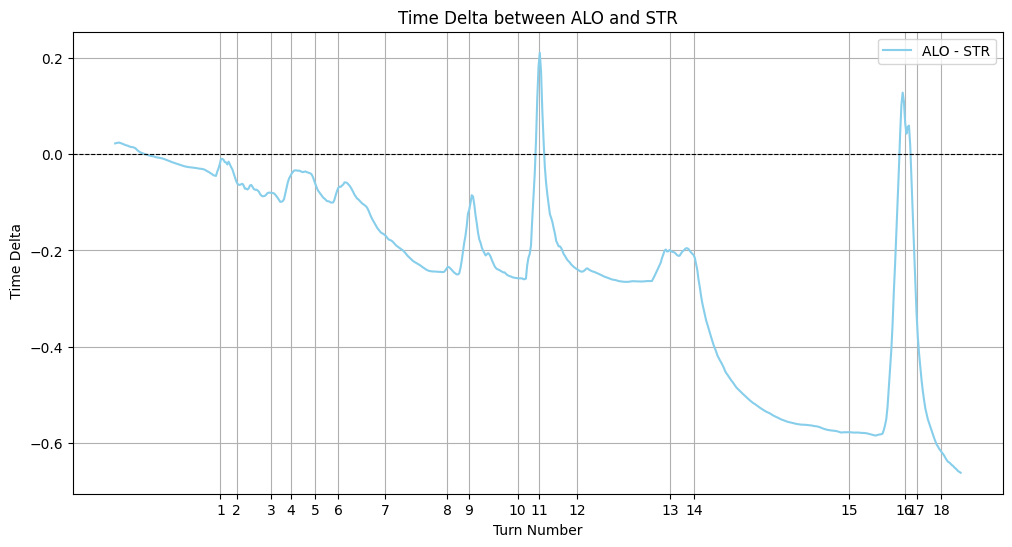

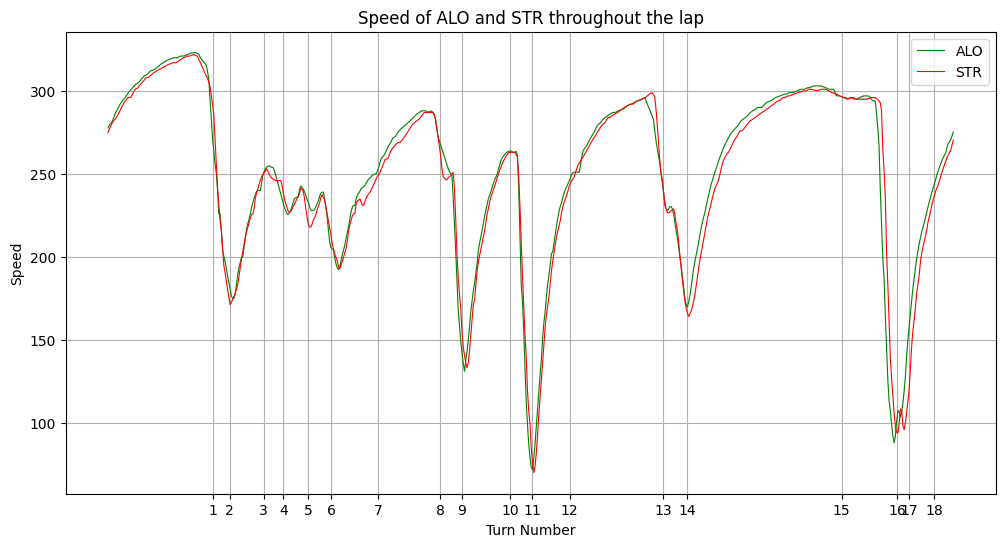

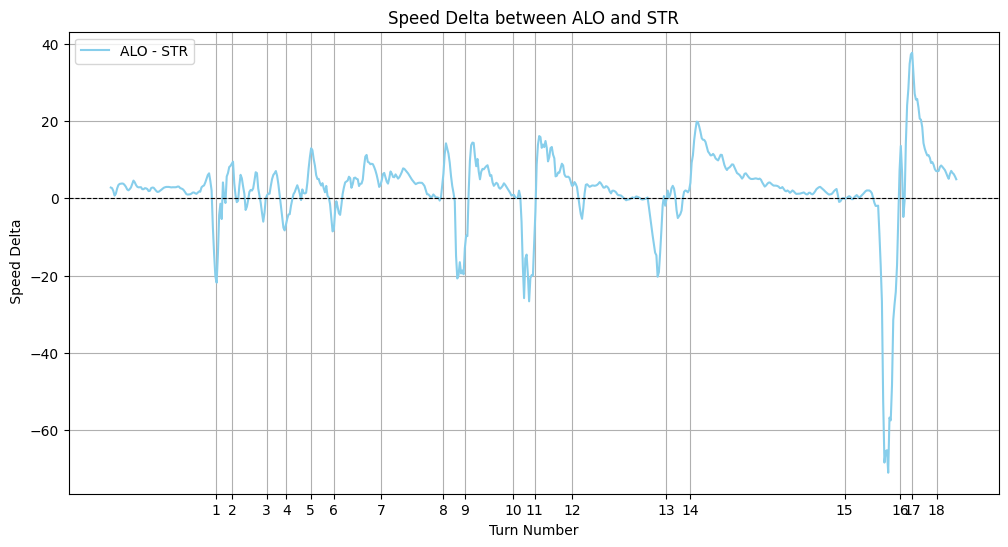

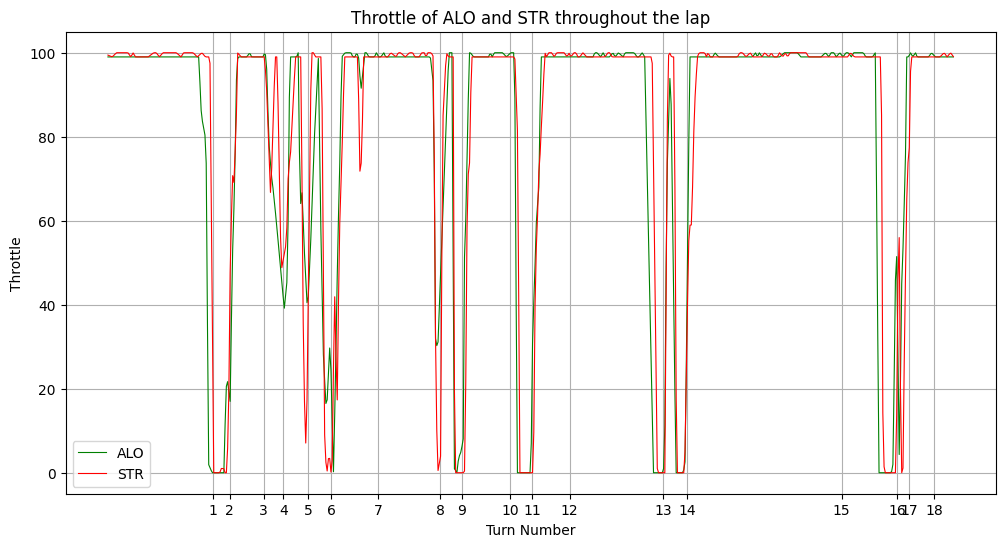

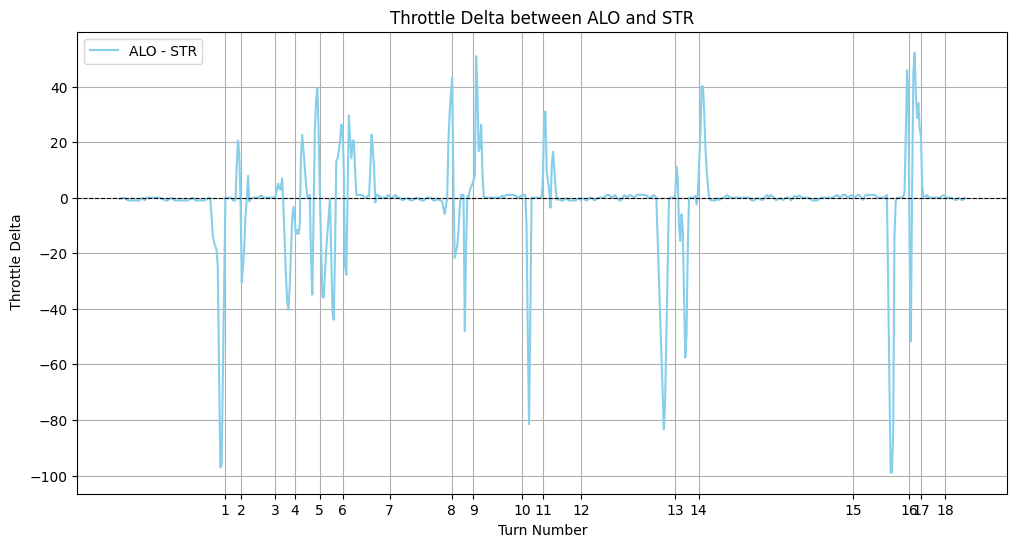

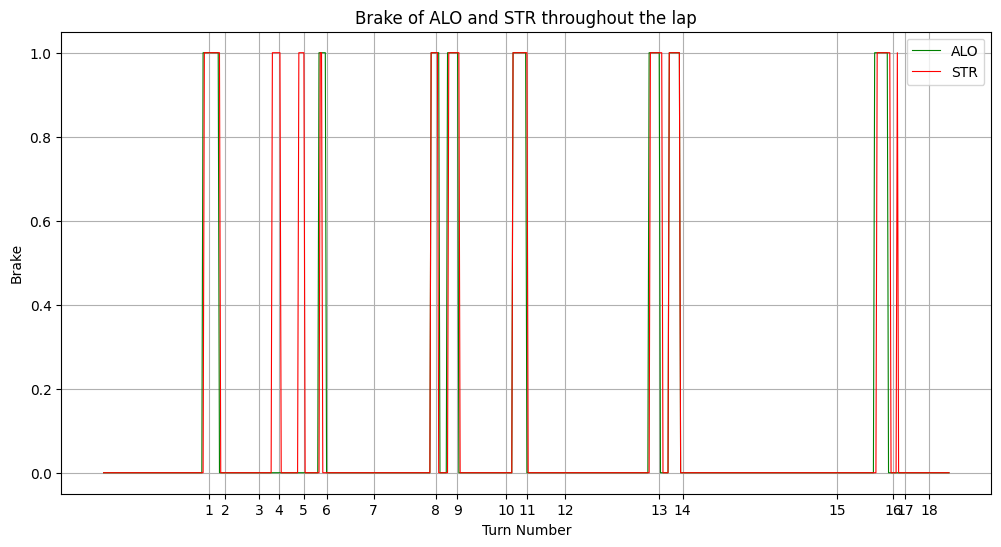

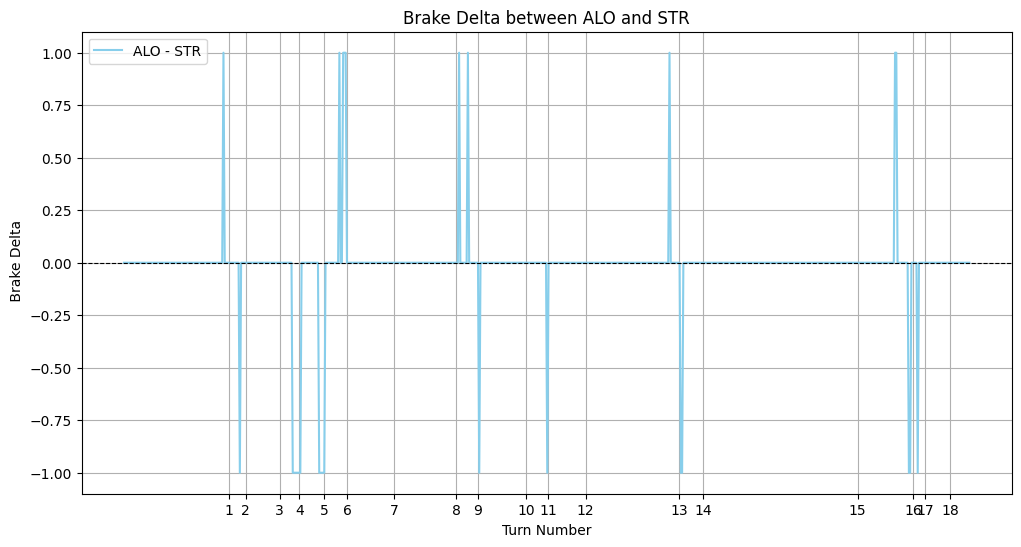

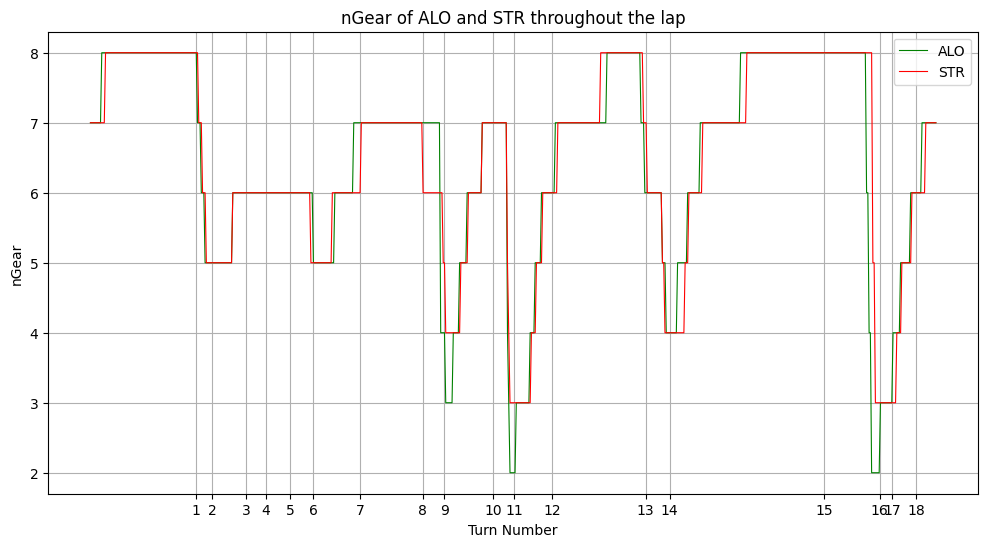

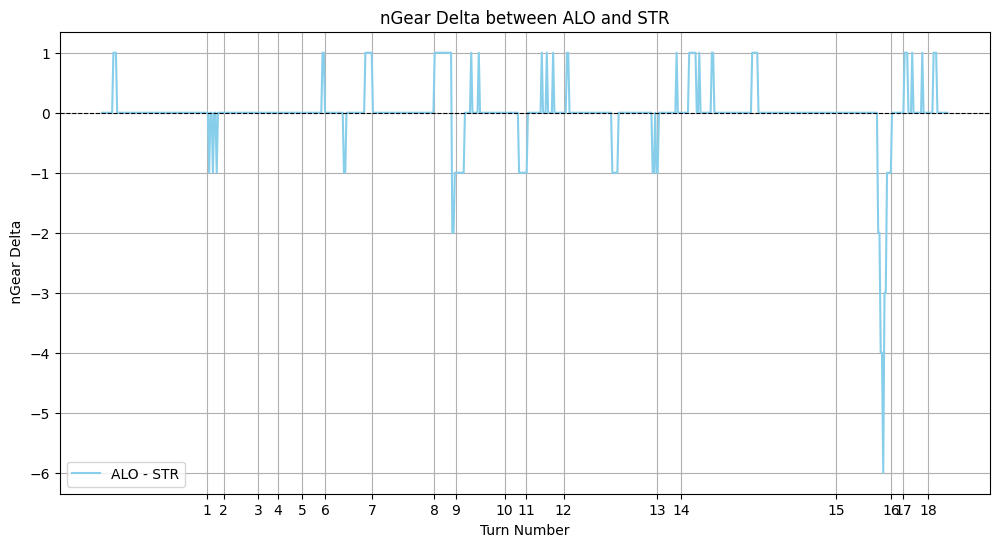

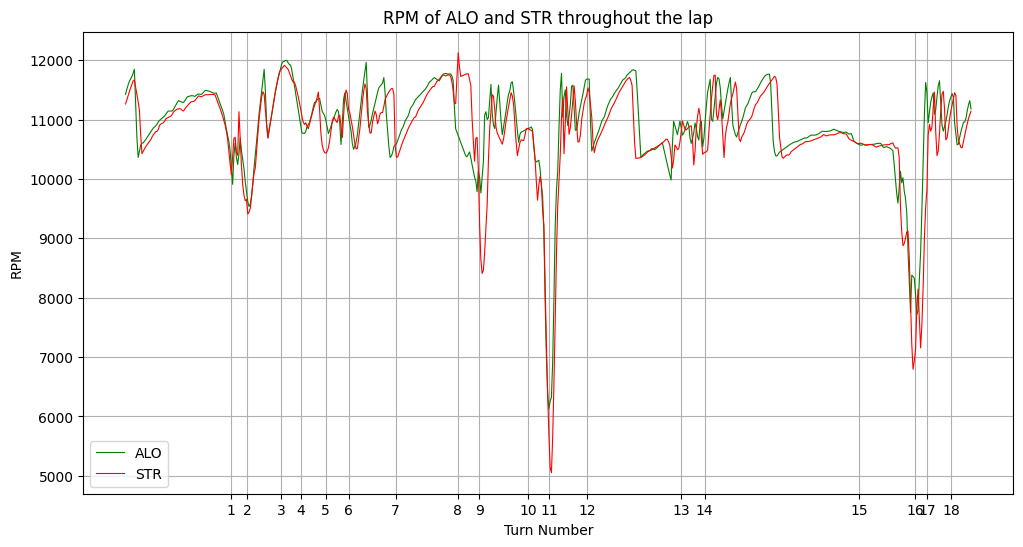

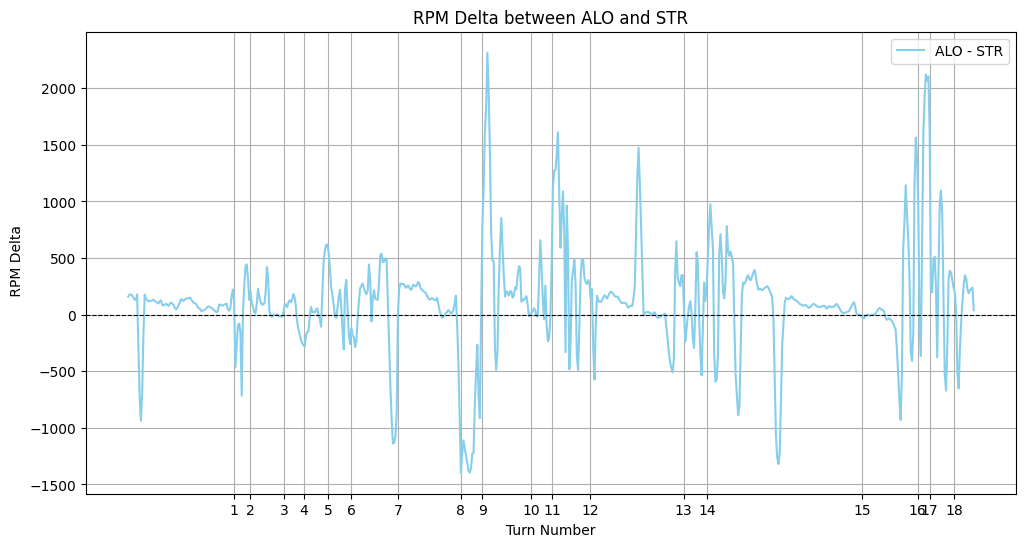

In [5]:
for variable in ["Time", "Speed", "Throttle","Brake","nGear", "RPM"]:
    plot_variable_comparison(lap_1["Telemetry"], lap_2["Telemetry"],variable, turns,  lap_1['Driver'], lap_2['Driver'])
    plot_variable_delta(lap_1["Telemetry"], lap_2["Telemetry"], lap_1['Driver'], lap_2['Driver'], variable, turns)